In [59]:
import numpy as np
import pandas as pd
import itertools
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

In [60]:
OUTPUT_DIR = r"C:\Courses\Innopolis\2026\ВЭД\Данные2"

In [61]:
df_port_congestion = pd.read_csv(f"{OUTPUT_DIR}\\fact_port_congestion.csv")
df_port_congestion["date"] = pd.to_datetime(df_port_congestion["date"])

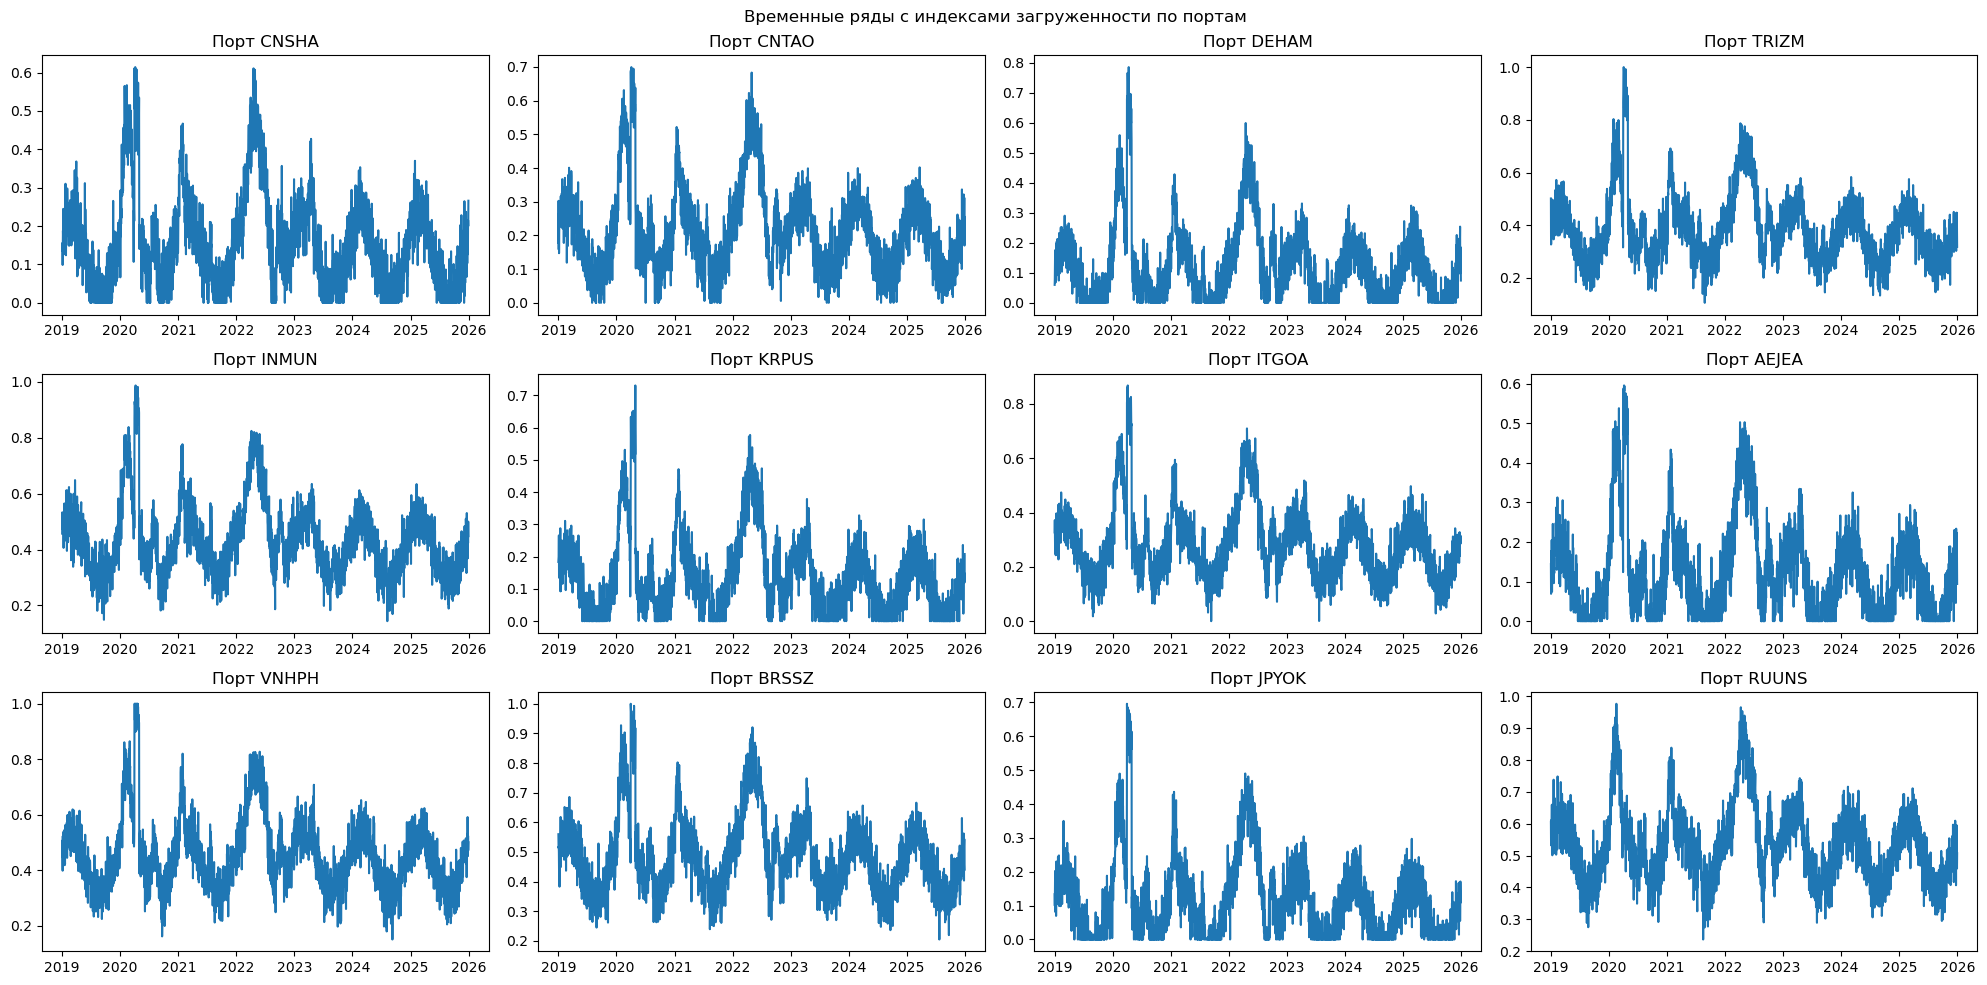

In [63]:
port_list = df_port_congestion["port_id"].unique().tolist()

fig, axes = plt.subplots(3,4, figsize = (20,10))
for i, ax in enumerate(axes.flatten()):
    df = df_port_congestion.loc[df_port_congestion["port_id"] == port_list[i], ["date", "congestion_index"]]
    df = df.set_index("date")
    ax.plot(df)
    #ax.get_legend().remove()
    ax.set_title(f"Порт {port_list[i]}")
plt.suptitle("Временные ряды с индексами загруженности по портам")
plt.tight_layout()
plt.show()

In [64]:
df_cnsha = df_port_congestion.loc[df_port_congestion["port_id"] == "CNSHA", ["date", "congestion_index"]]
df_cnsha = df_cnsha.set_index("date")
#df_cnsha = df_cnsha.resample("MS").mean()
df_cnsha

,congestion_index
date,
2019-01-01,0.1366
2019-01-02,0.1560
2019-01-03,0.1429
2019-01-04,0.0987
2019-01-05,0.1351
...,...
2025-12-27,0.1423
2025-12-28,0.1266
2025-12-29,0.2154


In [ ]:
FREQ = "MS"
PERIOD = 365
TEST_SIZE = 365
T_FORECAST = 365
N_SPLITS = 5
ALPHA = 0.05

In [66]:
def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
 
 
def evaluate_model(y_true, y_pred):
    print("MAE : ",   np.round(mean_absolute_error(y_true, y_pred),4))
    print("RMSE : ", np.round(np.sqrt(mean_squared_error(y_true, y_pred)),4))
    print("MAPE : ", np.round(mape(y_true, y_pred),4))
    print("R2 : ", np.round(r2_score(y_true, y_pred),4))

def plot_forecast(train, test, fcst, ci = None):
    fig, ax = plt.subplots(1,1, figsize = (15,5))
    ax.plot(train.index, train, color="#aec7e8", linewidth=1.2, label="Обучающая")
    ax.plot(test.index, test, color="#1f77b4", linewidth=1.8, label="Тестовая")
    ax.plot(fcst.index, fcst, color="#d62728", linewidth=1.6, linestyle="--", label="Прогноз")
    ax.axvline(test.index[0], color="gray", linestyle=":", linewidth=1.2)
    if (ci is None) or (ci.empty):
        pass
    else:
        ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, color="#d62728", label=f"{int((1-ALPHA)*100)}% CI")
    ax.set_title(f"Фактические значения против прогнозных")
    plt.show()

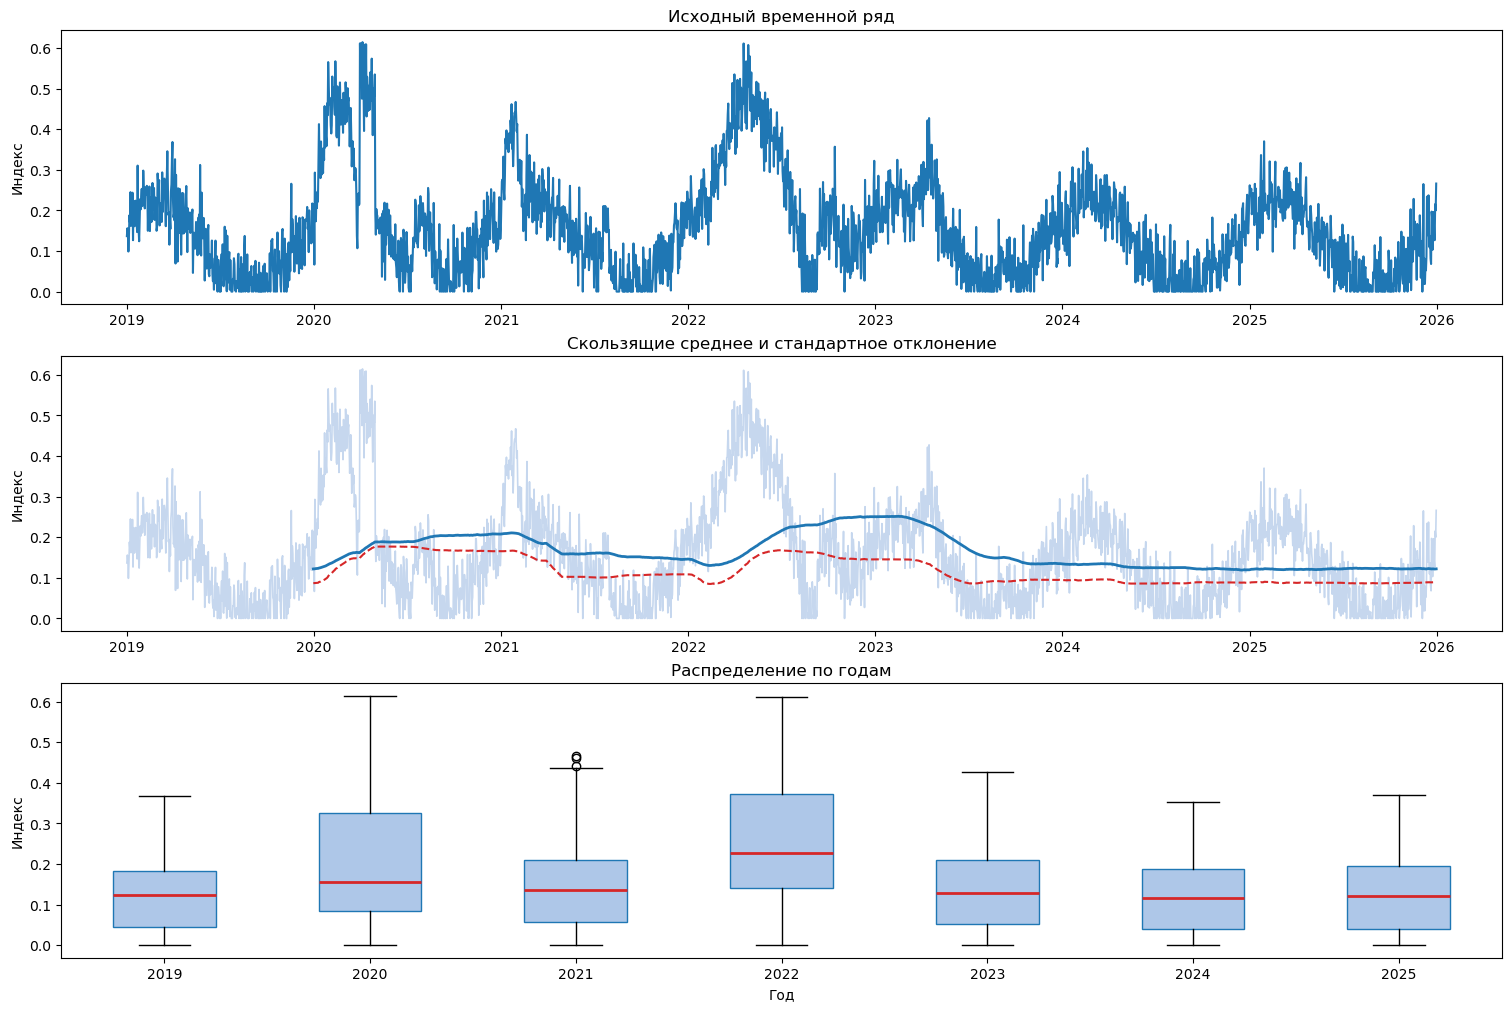

In [67]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), constrained_layout=True)
 
axes[0].plot(df_cnsha, color="#1f77b4")
axes[0].set_title("Исходный временной ряд")
axes[0].set_ylabel("Индекс")
 
roll_mean = df_cnsha.rolling(PERIOD).mean()
roll_std  = df_cnsha.rolling(PERIOD).std()

axes[1].plot(df_cnsha, color="#aec7e8", linewidth=1.2, alpha=0.7, label="Исходный ряд")
axes[1].plot(roll_mean, color="#1f77b4", linewidth=2.0, label=f"Скользящая средняя (w={PERIOD})")
axes[1].plot(roll_std,  color="#d62728", linewidth=1.5, linestyle="--", label=f"Скользящее стандартное отклонение (w={PERIOD})")
axes[1].set_title("Скользящие среднее и стандартное отклонение")
axes[1].set_ylabel("Индекс")

df_box = df_cnsha.copy()
df_box["year"] = df_cnsha.index.year
years = sorted(df_box["year"].unique())
data_by_year = [df_box.loc[df_box["year"] == y, "congestion_index"].values for y in years]
bp = axes[2].boxplot(data_by_year, labels=years, patch_artist=True, boxprops=dict(facecolor="#aec7e8", color="#1f77b4"), medianprops=dict(color="#d62728", linewidth=2))
axes[2].set_title("Распределение по годам")
axes[2].set_xlabel("Год")
axes[2].set_ylabel("Индекс")

plt.show()

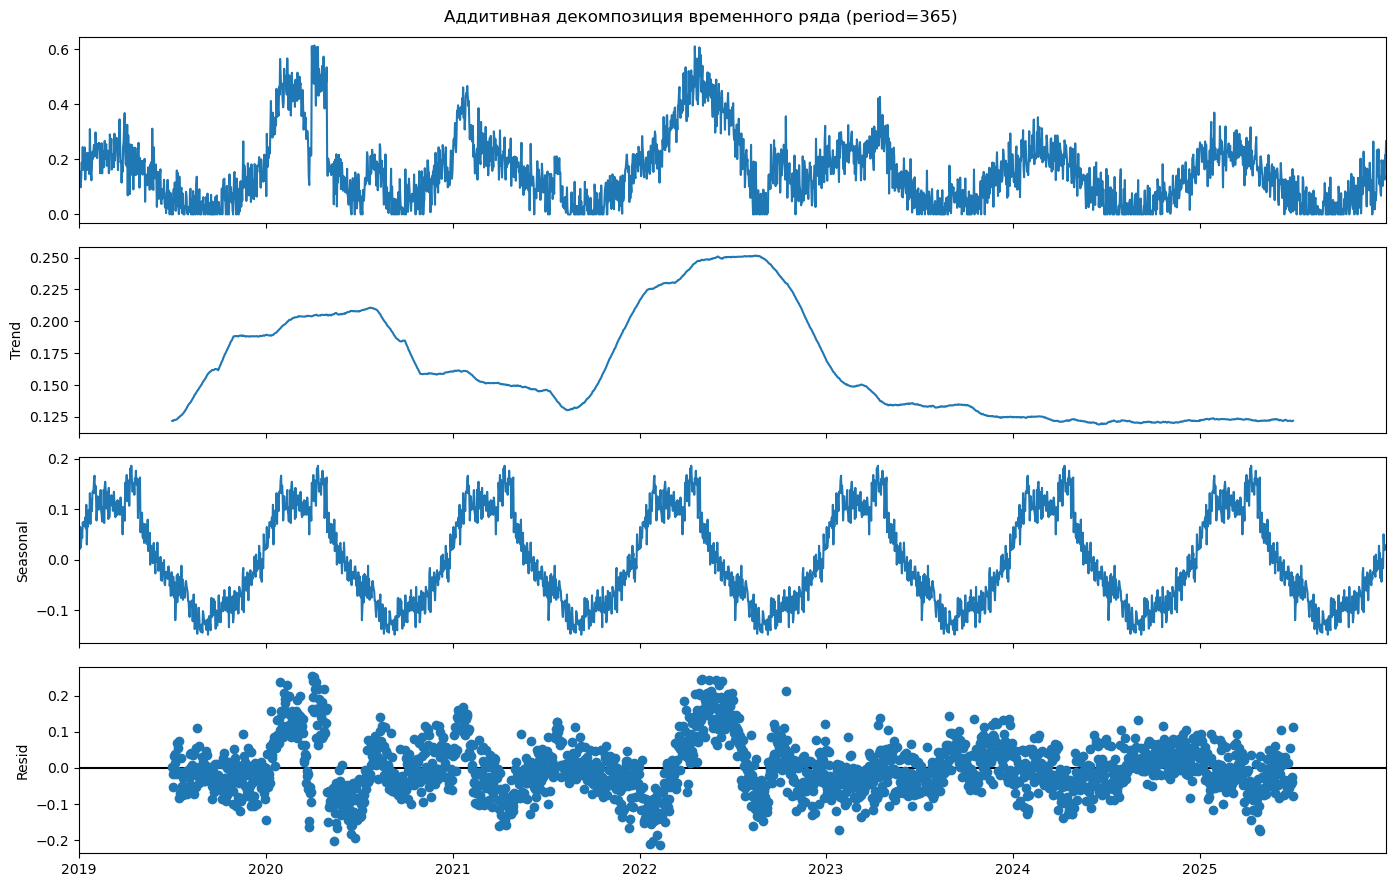

: 

In [ ]:
decomp = seasonal_decompose(df_cnsha, model="additive", period = PERIOD)
fig2 = decomp.plot()
fig2.set_size_inches(14, 9)
fig2.suptitle(f"Аддитивная декомпозиция временного ряда (period={PERIOD})")
plt.tight_layout()
plt.show()

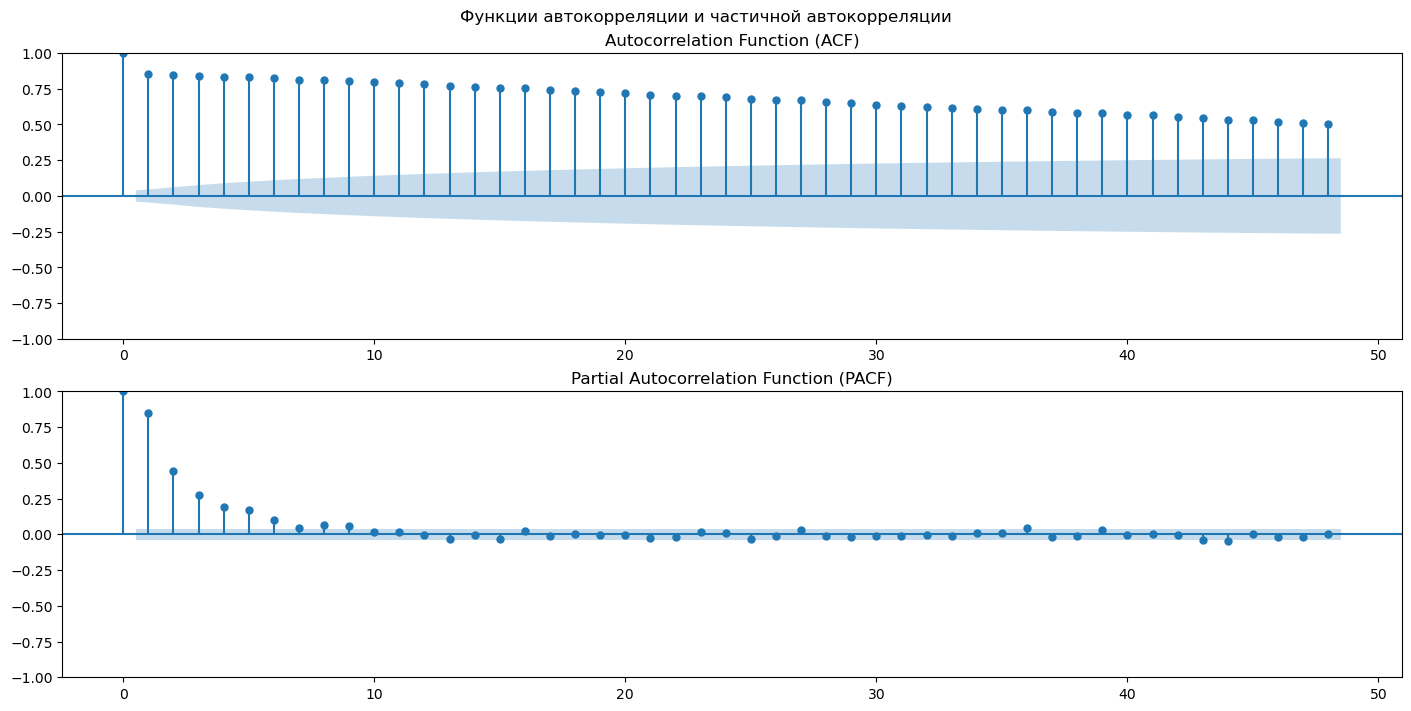

In [68]:
fig3, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), constrained_layout=True)
fig3.suptitle("Функции автокорреляции и частичной автокорреляции")
plot_acf(df_cnsha,  lags=48, ax=ax1, title="Autocorrelation Function (ACF)")
plot_pacf(df_cnsha, lags=48, ax=ax2, title="Partial Autocorrelation Function (PACF)", method="ywm")
plt.show()

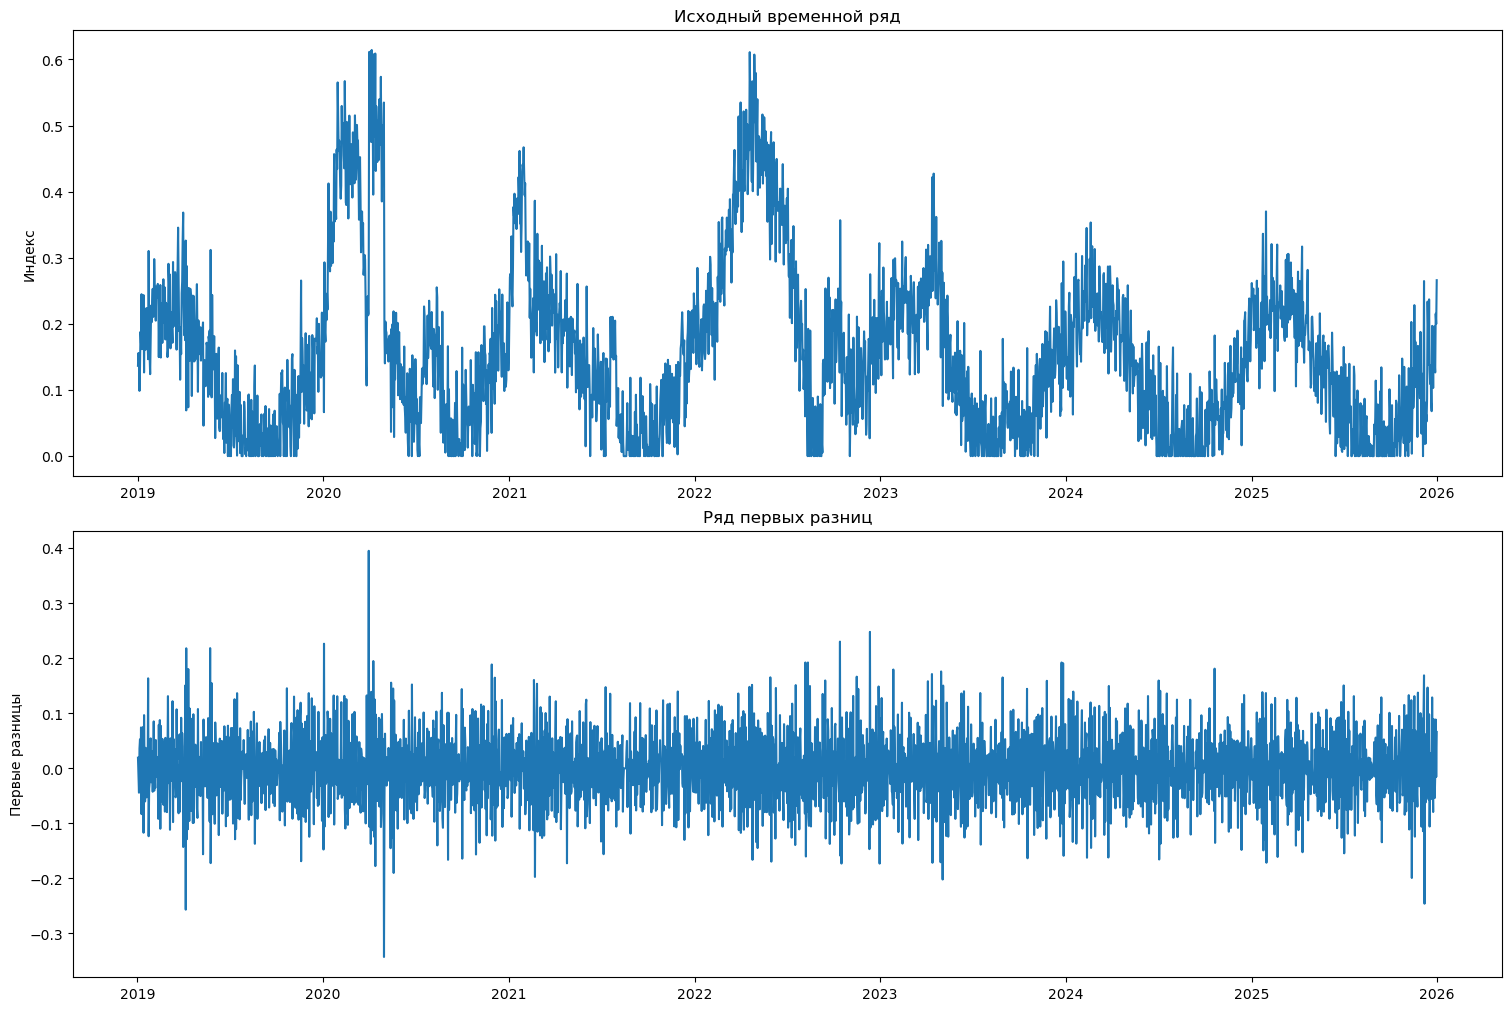

: 

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), constrained_layout=True)
 
axes[0].plot(df_cnsha, color="#1f77b4")
axes[0].set_title("Исходный временной ряд")
axes[0].set_ylabel("Индекс")
 
roll_mean = df_cnsha.rolling(PERIOD).mean()
roll_std  = df_cnsha.rolling(PERIOD).std()

axes[1].plot(df_cnsha.diff(), color="#1f77b4")
axes[1].set_title("Ряд первых разниц")
axes[1].set_ylabel("Первые разницы")

plt.show()

In [69]:
def run_adf(ts: pd.Series, label: str = "") -> bool:
    res = adfuller(ts.dropna(), autolag="AIC")
    stat, pval = res[0], res[1]
    conclusion = "Stationary" if pval < 0.05 else "Non-stationary"
    print(f"\n  ADF — {label}")
    print(f"    Test statistic : {stat:.4f}   p-value : {pval:.4f}")
    for k, v in res[4].items():
        print(f"    Critical ({k})  : {v:.4f}")
    print(f"    → {conclusion}")
    return pval < 0.05
 
 
def run_kpss(ts: pd.Series, label: str = "") -> bool:
    """Returns True if the series is stationary at 5 % level (KPSS)."""
    stat, pval, lags, crit = kpss(ts.dropna(), regression="c", nlags="auto")
    conclusion = "Stationary" if pval > 0.05 else "Non-stationary"
    print(f"\n  KPSS — {label}")
    print(f"    Test statistic : {stat:.4f}   p-value : {pval:.4f}   lags used : {lags}")
    print(f"    → {conclusion}")
    return pval > 0.05
 
 
# Level
run_adf(df_cnsha,  "Level")
run_kpss(df_cnsha, "Level")
 
# First difference
df_cnsha_d1 = df_cnsha.diff().dropna()
run_adf(df_cnsha_d1,  "First Difference (d=1)")
run_kpss(df_cnsha_d1, "First Difference (d=1)")


  ADF — Level
    Test statistic : -3.3189   p-value : 0.0141
    Critical (1%)  : -3.4329
    Critical (5%)  : -2.8627
    Critical (10%)  : -2.5674
    → Stationary

  KPSS — Level
    Test statistic : 0.5052   p-value : 0.0405   lags used : 30
    → Non-stationary

  ADF — First Difference (d=1)
    Test statistic : -25.9504   p-value : 0.0000
    Critical (1%)  : -3.4329
    Critical (5%)  : -2.8627
    Critical (10%)  : -2.5674
    → Stationary

  KPSS — First Difference (d=1)
    Test statistic : 0.0255   p-value : 0.1000   lags used : 86
    → Stationary


np.True_

In [70]:
# Use only the training portion for model selection to avoid data leakage
train = df_cnsha[:'2024']
test  = df_cnsha['2025':]
print(f"Обучающая выборка : {len(train)}")
print(f"Тестовая выборка : {len(test)}")

Обучающая выборка : 2192
Тестовая выборка : 365


# Наивная модель

In [109]:
train_fcst = train.shift(365).loc[:'2024']
test_fcst = pd.DataFrame(train.shift(365).loc['2024'].drop('2024-02-29').values, index = test.index)

In [ ]:
errors = train[PERIOD:] - train.shift(PERIOD)

n_boot = 10000

boot_errors = np.random.choice(
    errors,
    size=(n_boot, h),
    replace=True
)

boot_forecasts = (
    forecast.values.reshape(1, -1)
    + boot_errors
)

In [110]:
print("Evaluate train sample")
evaluate_model(train.loc['2020':'2024'], train_fcst.loc['2020':'2024'])

print("Evaluate test sample")
evaluate_model(test, test_fcst)

Evaluate train sample
MAE :  0.111
RMSE :  0.1497
MAPE :  244.3184
R2 :  -0.2584
Evaluate test sample
MAE :  0.0546
RMSE :  0.0708
MAPE :  115.4111
R2 :  0.3653


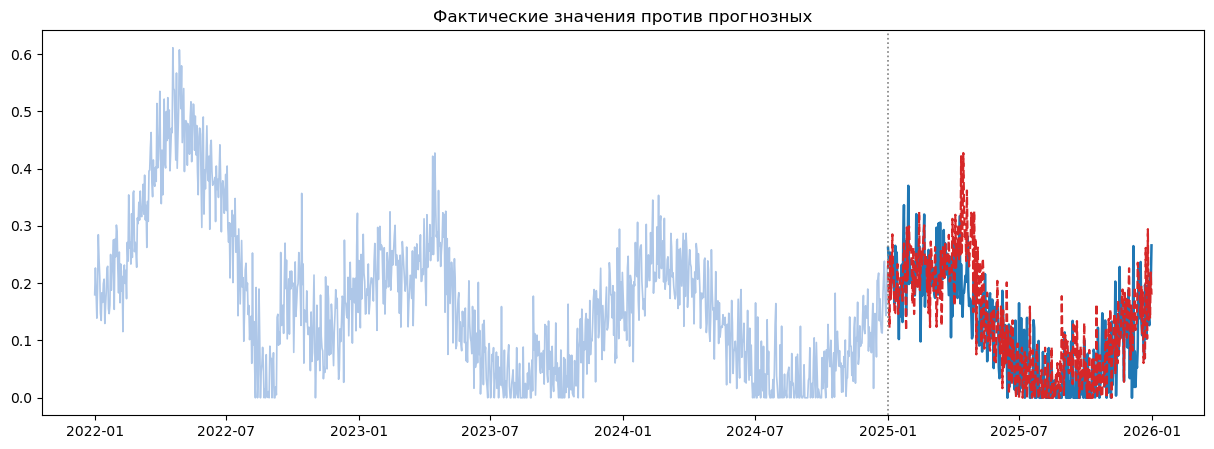

In [72]:
plot_forecast(train.loc['2022':], test, test_fcst)

# Аддитивная декомпозиция + ARIMA

In [78]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA

stl = STL(train, period=365, robust = True)
stl_fit = stl.fit()

seasonal = stl_fit.seasonal
trend = stl_fit.trend
residuals = stl_fit.resid

arima_model = ARIMA(residuals, order=(1,0,1))

arima_fit = arima_model.fit()
print(arima_fit.summary())

c:\Users\D\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\D\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\D\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  resid   No. Observations:                 2192
Model:                 ARIMA(1, 0, 1)   Log Likelihood                3317.456
Date:                Mon, 08 Jun 2026   AIC                          -6626.913
Time:                        14:56:23   BIC                          -6604.142
Sample:                    01-01-2019   HQIC                         -6618.591
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0225      0.018      1.272      0.203      -0.012       0.057
ar.L1          0.9831      0.003    305.137      0.000       0.977       0.989
ma.L1         -0.7543      0.010    -78.841      0.0

In [84]:
resid_forecast = arima_fit.get_forecast(steps=T_FORECAST)
resid_mean = resid_forecast.predicted_mean
resid_ci = resid_forecast.conf_int(alpha=0.05)

last_trend = trend.iloc[-1]
trend_forecast = pd.Series(last_trend,index=resid_mean.index)

last_season = seasonal.iloc[-PERIOD:]

seasonal_forecast = pd.Series(
    np.resize(last_season.values, T_FORECAST),
    index=resid_mean.index
)


In [87]:
test_fcst = (
trend_forecast
    + seasonal_forecast
    + resid_mean
)

fcst_lower = (
    trend_forecast
    + seasonal_forecast
    + resid_ci.iloc[:, 0]
)

fcst_upper = (
    trend_forecast
    + seasonal_forecast
    + resid_ci.iloc[:, 1]
)

forecast_df = pd.DataFrame({
    "forecast": test_fcst,
    "lower_95": fcst_lower,
    "upper_95": fcst_upper
})

print(forecast_df.head())


            forecast  lower_95  upper_95
2025-01-01  0.120991  0.016628  0.225354
2025-01-02  0.091026 -0.016035  0.198086
2025-01-03  0.153822  0.044217  0.263427
2025-01-04  0.121735  0.009726  0.233744
2025-01-05  0.120102  0.005816  0.234387


In [96]:
print("Evaluate test sample")
evaluate_model(test, test_fcst.to_frame())

Evaluate test sample
MAE :  0.0544
RMSE :  0.0678
MAPE :  152.7995
R2 :  0.4183


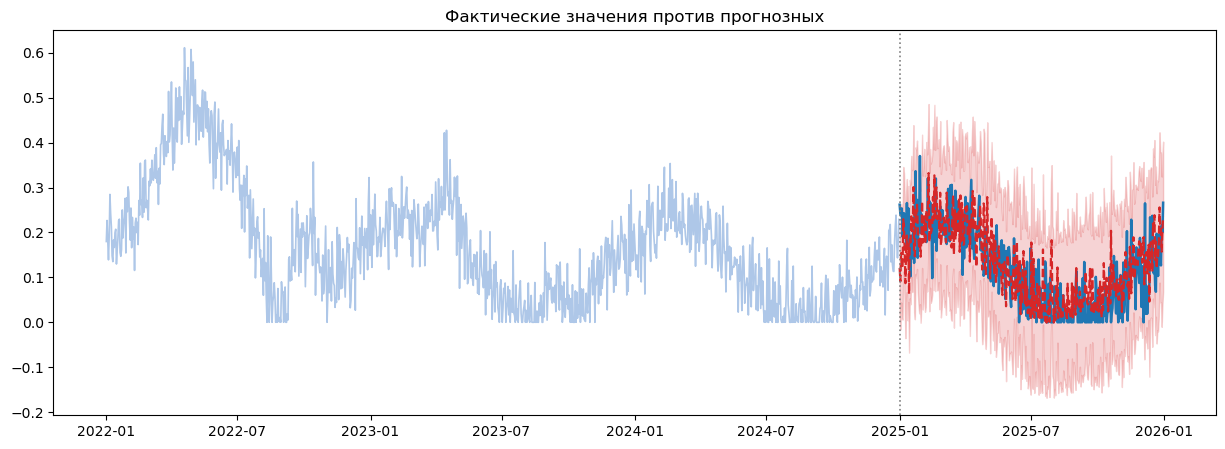

In [108]:
plot_forecast(train.loc['2022':], test, test_fcst, forecast_df[["lower_95", "upper_95"]])

# Синусоида

In [111]:
def fourier_terms(index, period, K):
    t = np.arange(len(index))
    X = pd.DataFrame(index=index)
    for k in range(1, K + 1):
        X[f'sin_{k}'] = np.sin(
            2 * np.pi * k * t / period
        )
        X[f'cos_{k}'] = np.cos(
            2 * np.pi * k * t / period
        )
    return X

In [112]:
X = fourier_terms(train.index, period=PERIOD, K=5)

In [128]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train, exog=X, order=(1,0,1), seasonal_order=(0,0,0,0), trend='c', freq = 'D')
fourier_fit = model.fit()

c:\Users\D\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\D\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [129]:
full_index = df_cnsha.index

X_full = fourier_terms(full_index, period=365, K=5)
X_test = X_full.loc["2025"]

In [130]:
fcst = fourier_fit.get_forecast(steps=PERIOD, exog=X_future)

In [131]:
test_fcst = fcst.predicted_mean
conf_int = fcst.conf_int(alpha=0.05)

In [132]:
print("Evaluate test sample")
evaluate_model(test, test_fcst.to_frame())

Evaluate test sample
MAE :  0.0515
RMSE :  0.0623
MAPE :  146.2553
R2 :  0.51


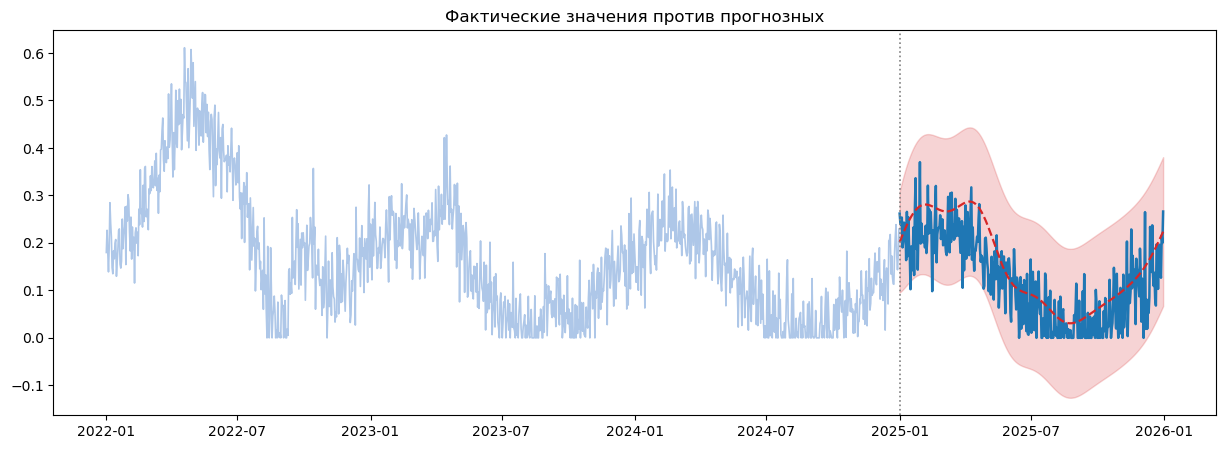

In [133]:
plot_forecast(train.loc['2022':], test, test_fcst, conf_int)

# LSTM

In [72]:
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [73]:
day_of_year = df_cnsha.index.dayofyear
df_cnsha["sin_year"] = np.sin(2 * np.pi * day_of_year / 365)
df_cnsha["cos_year"] = np.cos(2 * np.pi * day_of_year / 365)

In [74]:
target_scaler = StandardScaler()
df_cnsha["congestion_index_scaled"] = target_scaler.fit_transform(df_cnsha[["congestion_index"]])
df_cnsha["congestion_index_scaled"] = np.nan

df_cnsha.loc[train.index, "congestion_index_scaled"] = target_scaler.fit_transform(train.values)
df_cnsha.loc[test.index, "congestion_index_scaled"] = target_scaler.transform(test.values.reshape(-1, 1))

In [79]:
LOOKBACK = 365
features = ["congestion_index_scaled","sin_year","cos_year"]

train_end_idx = len(df_cnsha) - TEST_SIZE

X_train = []
y_train = []

for i in range(LOOKBACK, train_end_idx):

    X_train.append(
        df_cnsha[features]
        .iloc[i-LOOKBACK:i]
        .values
    )

    y_train.append(
        df_cnsha["congestion_index_scaled"]
        .iloc[i]
    )

X_train = np.array(X_train)
y_train = np.array(y_train)

print(X_train.shape)

(1827, 365, 3)


In [80]:
class TimeSeriesDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X,dtype=torch.float32)
        self.y = torch.tensor(y,dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (self.X[idx],self.y[idx])

In [81]:
train_ds = TimeSeriesDataset(X_train,y_train)
train_loader = DataLoader(train_ds,batch_size=32,shuffle=True)

In [82]:
class LSTMModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=3,
            hidden_size=64,
            num_layers=2,
            dropout=0.2,
            batch_first=True
        )
        self.fc = nn.Linear(64,1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze()

In [83]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [84]:
EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    losses = []
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)

        loss = criterion(pred,yb)

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    print(epoch,np.mean(losses))

0 0.4962608340228426
1 0.20920490884575352
2 0.20445163625067678
3 0.19017720248164802
4 0.1884146877403917
5 0.18852491599732432
6 0.18527439300870074
7 0.18503131550447693
8 0.19204662226397415
9 0.19001877333583503
10 0.18710079018411965
11 0.18152822798182225
12 0.18982569976099606
13 0.18506581105034928
14 0.18963891113626546
15 0.18932893127202988
16 0.1831592331672537
17 0.18754115636492596
18 0.17964343855093265
19 0.18518956904781275
20 0.1787973408876308
21 0.18456949550530005
22 0.18561116426155486
23 0.184127788990736
24 0.18195453812849932
25 0.181818635299288
26 0.1797648524415904
27 0.18123262080139127
28 0.18014411268563107
29 0.1805353467834407
30 0.17787637905185594
31 0.18064752028420053
32 0.18498528196380057
33 0.17840218197168975
34 0.1799732525672378
35 0.17945853132626105
36 0.17990881384446702
37 0.1773779981865965
38 0.1771764593391583
39 0.177155621992103
40 0.18153682890637168
41 0.1808347506769772
42 0.17501715127507161
43 0.1754016849244463
44 0.1751967473

In [85]:
window = df_cnsha[features].iloc[train_end_idx-LOOKBACK:train_end_idx].values.copy()

In [86]:
model.eval()
predictions = []
with torch.no_grad():
    for i in range(TEST_SIZE):
        x = torch.tensor(window,dtype=torch.float32).unsqueeze(0)
        x = x.to(device)
        pred = model(x)
        pred = pred.cpu().item()
        predictions.append(pred)
        
        next_row = np.array([
            pred,
            df_cnsha["sin_year"].iloc[train_end_idx + i],
            df_cnsha["cos_year"].iloc[train_end_idx + i]
        ])

        window = np.vstack([
            window[1:],
            next_row
        ])

In [87]:
test_fcst = target_scaler.inverse_transform(np.array(predictions).reshape(-1,1)).flatten()

forecast = pd.Series(test_fcst, index=test.index)

In [92]:
print("Evaluate test sample")
evaluate_model(test, pd.DataFrame(test_fcst))

Evaluate test sample
MAE :  0.0394
RMSE :  0.0485
MAPE :  95.1492
R2 :  0.7026


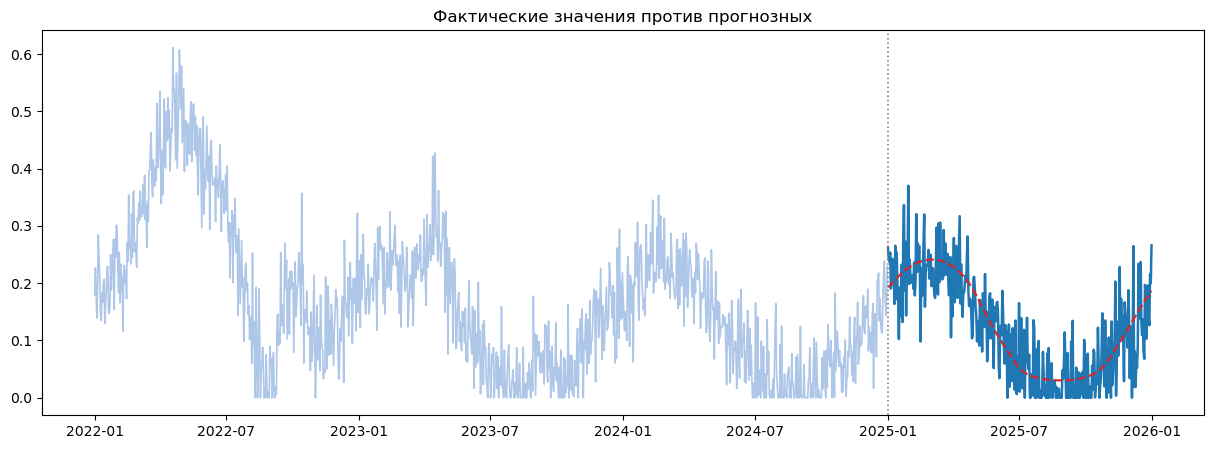

In [95]:
plot_forecast(train.loc['2022':], test, pd.DataFrame(test_fcst, index = test.index))